# **LAB ASSIGNMENT - 4**

**Install & Import All Required Libraries**

In [ ]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import time

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Conv2D, MaxPooling2D, Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
print("All required libraries imported successfully.")

All required libraries imported successfully.


**Data Preparation**

In [ ]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Data:", x_train.shape, y_train_cat.shape)
print("Testing Data:", x_test.shape, y_test_cat.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Data: (50000, 32, 32, 3) (50000, 10)
Testing Data: (10000, 32, 32, 3) (10000, 10)


**ANN Model**

In [ ]:
def build_ann(optimizer='adam', activation='relu'):
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation=activation),
        Dense(256, activation=activation),
        Dense(128, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

ann_model = build_ann(optimizer=Adam())
ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

**CNN Model**

In [ ]:
def build_cnn(optimizer='adam'):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=(32,32,3)),
        MaxPooling2D((2,2)),

        Conv2D(64, (5,5), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(128, (7,7), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_model = build_cnn(optimizer=Adam())
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,258 (2.74 MB)

 Trainable params: 717,258 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

**Train ANN Model**

In [ ]:
ann_model = build_ann(optimizer=Adam())

start_time = time.time()
ann_history = ann_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
ann_training_time = time.time() - start_time
print("ANN Training Time (seconds):", ann_training_time)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.2637 - loss: 2.0226 - val_accuracy: 0.3638 - val_loss: 1.7914
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.3806 - loss: 1.7200 - val_accuracy: 0.4105 - val_loss: 1.6635
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.4220 - loss: 1.6223 - val_accuracy: 0.4286 - val_loss: 1.6227
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4393 - loss: 1.5554 - val_accuracy: 0.4433 - val_loss: 1.5853
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.4611 - loss: 1.5081 - val_accuracy: 0.4460 - val_loss: 1.5537
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.4767 - loss: 1.4606 - val_accuracy: 0.4576 - val_loss: 1.5281
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.4820 - loss: 1.4330 - val_accuracy: 0.4621 - val_loss: 1.5203
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.4961 - loss: 1.4007 - 

**Train CNN Model**

In [ ]:
cnn_model = build_cnn(optimizer=Adam())

start_time = time.time()
cnn_history = cnn_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

cnn_training_time = time.time() - start_time
print("CNN Training Time (seconds):", cnn_training_time)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 344s 547ms/step - accuracy: 0.2921 - loss: 1.8962 - val_accuracy: 0.5402 - val_loss: 1.2827
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 323s 516ms/step - accuracy: 0.5268 - loss: 1.3277 - val_accuracy: 0.6190 - val_loss: 1.0619
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 324s 518ms/step - accuracy: 0.6247 - loss: 1.0686 - val_accuracy: 0.6829 - val_loss: 0.8973
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 513ms/step - accuracy: 0.6899 - loss: 0.9055 - val_accuracy: 0.7093 - val_loss: 0.8358
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 511ms/step - accuracy: 0.7312 - loss: 0.7842 - val_accuracy: 0.7212 - val_loss: 0.8069
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 511ms/step - accuracy: 0.7669 - loss: 0.6756 - val_accuracy: 0.7226 - val_loss: 0.8317
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 510ms/step - accuracy: 0.7991 - loss: 0.5795 - val_accuracy: 0.7400 - val_loss: 0.7760
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 317s 507ms/step - accuracy: 0.8297 -

**Model Evaluation (ANN + CNN)**

In [ ]:
# ANN Evaluation
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test, y_test_cat, verbose=0)

# CNN Evaluation
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

print("ANN Test Accuracy:", ann_test_acc)
print("CNN Test Accuracy:", cnn_test_acc)

ANN Test Accuracy: 0.4887999892234802
CNN Test Accuracy: 0.7297000288963318


**Confusion Matrix & Classification Metrics**

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.50      0.53      1000
           1       0.59      0.64      0.62      1000
           2       0.41      0.32      0.36      1000
           3       0.31      0.33      0.32      1000
           4       0.43      0.40      0.41      1000
           5       0.42      0.35      0.38      1000
           6       0.48      0.62      0.54      1000
           7       0.60      0.49      0.54      1000
           8       0.53      0.71      0.61      1000
           9       0.54      0.54      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



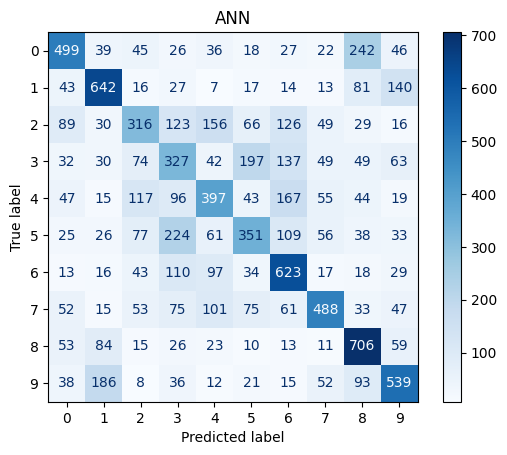

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step

CNN Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.67      0.74      1000
           1       0.90      0.82      0.86      1000
           2       0.58      0.70      0.64      1000
           3       0.52      0.56      0.54      1000
           4       0.64      0.75      0.69      1000
           5       0.71      0.52      0.60      1000
           6       0.78      0.79      0.79      1000
           7       0.80      0.79      0.79      1000
           8       0.80      0.86      0.83      1000
           9       0.83      0.84      0.83      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



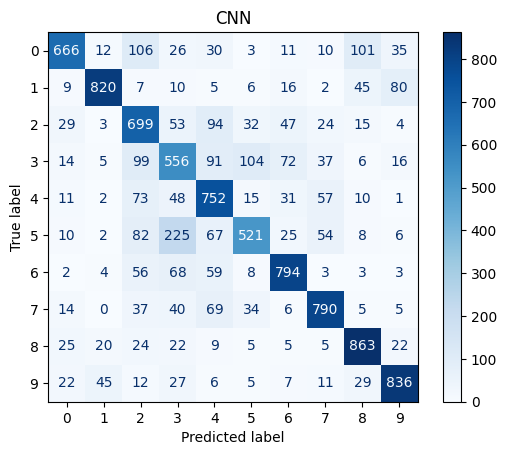

In [ ]:
def evaluate_model(model, x_test, y_test_cat, title):
    y_pred = np.argmax(model.predict(x_test), axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    print(f"\n{title} Classification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

# ANN Metrics
evaluate_model(ann_model, x_test, y_test_cat, "ANN")

# CNN Metrics
evaluate_model(cnn_model, x_test, y_test_cat, "CNN")

**Training vs Validation Curves**

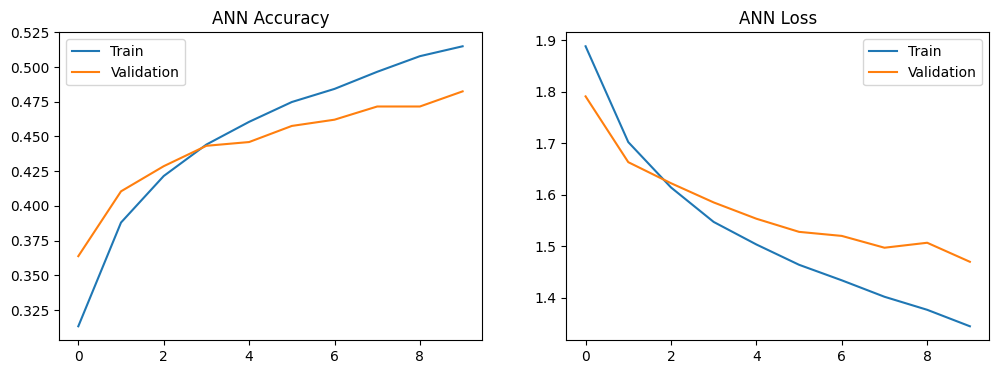

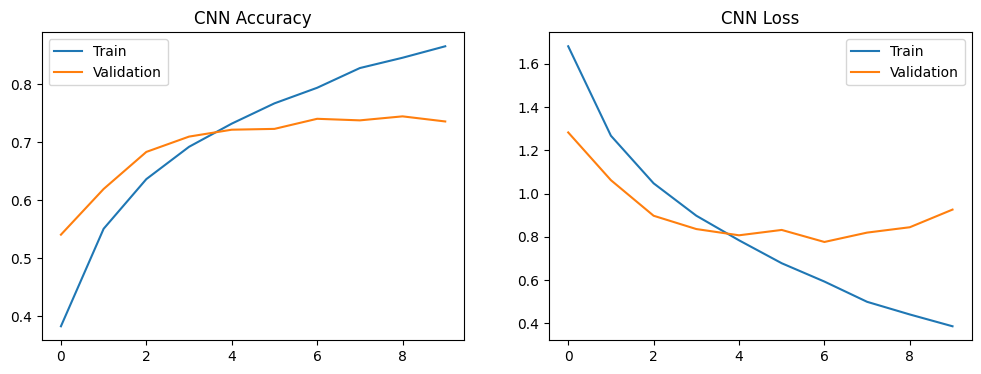

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

plot_history(ann_history, "ANN")
plot_history(cnn_history, "CNN")

**Misclassified Images (CNN)**

In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step


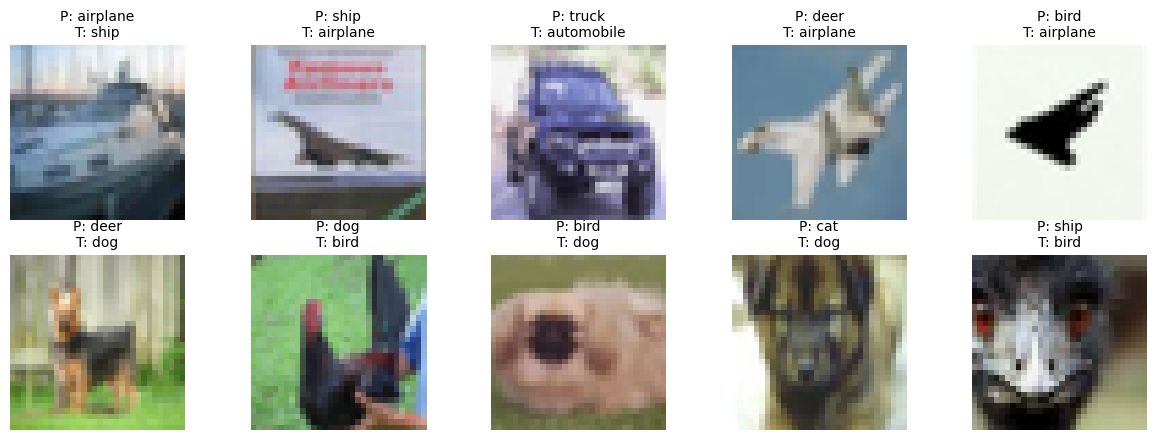

In [ ]:
y_pred = np.argmax(cnn_model.predict(x_test), axis=1)
y_true = np.argmax(y_test_cat, axis=1)

misclassified = np.where(y_pred != y_true)[0][:10]

plt.figure(figsize=(15,5))
for i, idx in enumerate(misclassified):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])

    pred_label = class_names[y_pred[idx]]
    true_label = class_names[y_true[idx]]

    plt.title(f"P: {pred_label}\nT: {true_label}", fontsize=10)
    plt.axis('off')

plt.show()

**Final Comparison Table**

In [ ]:
print("Model Comparison Summary\n")
print("Model | Parameters | Test Accuracy | Training Time")
print("---------------------------------------------------")
print(f"ANN  | {ann_model.count_params()} | {ann_test_acc:.4f} | {ann_training_time:.2f}s")
print(f"CNN  | {cnn_model.count_params()} | {cnn_test_acc:.4f} | {cnn_training_time:.2f}s")

Model Comparison Summary

Model | Parameters | Test Accuracy | Training Time
---------------------------------------------------
ANN  | 1738890 | 0.4888 | 250.97s
CNN  | 717258 | 0.7297 | 3234.54s


**Summary:**

In this assignment, we carried out CIFAR-10 image classification using both an Artificial Neural Network (ANN) and a Convolutional Neural Network (CNN). We preprocessed the dataset by normalizing pixel values and applying one-hot encoding to class labels. We reused the ANN model with three hidden layers from the previous assignment. We also designed a CNN with three convolutional layers of varying filter sizes to capture spatial features from the images. Both models were trained and evaluated using the same dataset and metrics. The experimental results indicated that the CNN achieved much higher accuracy and better generalization than the ANN. This shows that CNNs are better suited for image classification tasks because they can learn spatial and hierarchical features.